In [1]:
%matplotlib inline
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance
from scipy import stats
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [2]:
"""
You can start the code from here
Here we import the table with counts data for all the samples in the termporat data
"""

#Import the actual data
df_biofilm_filtered = pd.read_csv('Figurewise raw data/Biofilm_filtered.csv', index_col = 0)
df_biofilm_filtered.head()

,3,8,28,32,42,64,70,78,100,108,...,t_27_enrichment,t_39_enrichment,t_45_enrichment,t_63_enrichment,t_73_enrichment,t_81_enrichment,t_99_enrichment,t_107_enrichment,t_115_enrichment,t_137_enrichment
barcode,,,,,,,,,,,,,,,,,,,,,
GCGTATCGGAACTAGAAGGG,0,1,7,3,1,0,3,1,3,3,...,0.301030,0.602060,0.301030,0.602060,1.255273,1.146128,0.903090,0.000000,0.000000,0.000000
ACTGGAGAGACGCTCCAAGT,0,5,1,0,2,0,1,2,0,0,...,0.301030,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.301030,0.000000
GTTTTTAAATGTGTGCCCGG,1,4,1,3,9,0,4,0,0,0,...,-0.301030,-0.301030,0.397940,0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030
GTACTAAATTGATGCCCATT,10,0,0,0,0,0,0,2,3,0,...,-0.740363,-1.041393,-1.041393,-0.740363,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393
GGCCAAAGTACCTGTTAAAT,7,4,4,4,6,10,5,9,3,4,...,-0.903090,-0.425969,0.096910,-0.903090,-0.903090,-0.425969,-0.903090,-0.903090,-0.425969,-0.903090


In [3]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import entropy
from scipy.spatial import distance

# Discs list
Discs = ['12','13','14','15','16','17','18','19','20','21','22','23']

# --- Precompute for speed ---
# Extract only needed columns as NumPy array
df_values = df_biofilm_filtered[Discs].to_numpy()

# Map column names to indices (fast lookup)
col_index = {col: i for i, col in enumerate(Discs)}

# Extract comparison vector once
t3f = df_biofilm_filtered["t_3_f"].to_numpy()

# Store results here (faster than growing DataFrames)
results = []

# --- Main computation ---
for n in range(1, len(Discs)):    
    for combo in itertools.combinations(Discs, n):
        
        # Convert column names → indices
        idx = [col_index[c] for c in combo]
        
        # Sum selected discs (vectorized)
        summed = df_values[:, idx].sum(axis=1)
        
        total = summed.sum()
        if total == 0:
            continue  # avoid division by zero
        
        # Normalize
        p = summed / total
        
        # Compute metrics
        shannon = entropy(p)
        bray = distance.braycurtis(t3f, p)
        Nb = len(summed[summed > 0])
        
        # Store result
        results.append((n, shannon, bray, Nb))

# --- Final DataFrame ---
df_shannonbray_data = pd.DataFrame(
    results,
    columns=['No_discs', 'Shannon', 'Distance', 'Nb']
)

# Display result
df_shannonbray_data.to_csv('Figurewise raw data/Supplementary figure 6.csv')

In [4]:
#import the disc prediction
df_predict = pd.read_csv(f'Simulation_final/run_-8.095_70_2.csv')
df_predict

,t_3_f,Disc_0,Disc_1,Disc_2,Disc_3,Disc_4,Disc_5,Disc_6,Disc_7,Disc_8,Disc_9,Disc_10,Disc_11,Disc_12,Disc_13,Disc_14,Disc_15,Disc_16,Disc_17
0,0.008848,23479,31123,21088,34689,40453,25970,24541,28200,23434,37300,32443,37317,29634,32912,33184,23933,22951,30472
1,0.006956,16355,29085,24807,19845,28552,28956,22926,23176,18287,22385,17458,29695,25588,21038,26214,16777,19710,15775
2,0.004340,18931,9027,14711,12667,16383,11711,13494,14764,17393,10253,13124,22276,17509,11241,13949,10337,9680,12495
3,0.004300,11495,10588,11108,12673,16567,13442,13220,10056,14284,14837,15518,13790,11424,15595,12937,17342,11689,11506
4,0.004112,23437,15921,15424,9277,12813,10302,16583,16134,8270,13027,14205,13716,16981,11442,16885,11762,10238,13813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169316,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
169317,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
169318,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
169319,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
"""
In the following code, we calculate the shannon entropy and bray curtis indices for the simulated disc.

This is to set up a baseline expectation for the observed results.
"""

import itertools
import numpy as np
import pandas as pd
import random
import math
from scipy.stats import entropy
from scipy.spatial import distance

num_discs = 18
discname_list = [f'Disc_{i}' for i in range(num_discs)]

# --- Precompute ---
df_values = df_predict[discname_list].to_numpy()
col_index = {col: i for i, col in enumerate(discname_list)}
t3f = df_predict["t_3_f"].to_numpy()

results = []
MAX_SAMPLES = 100

# --- Main loop ---
for n in range(0, len(discname_list)+1):

    total_combos = math.comb(len(discname_list), n)
    
    if total_combos <= MAX_SAMPLES:
        combos = itertools.combinations(discname_list, n)
    else:
        combos = (
            tuple(random.sample(discname_list, n))
            for _ in range(MAX_SAMPLES)
        )

    for combo in combos:
        idx = [col_index[c] for c in combo]

        summed = df_values[:, idx].sum(axis=1)

        total = summed.sum()
        if total == 0:
            continue

        p = summed / total

        shannon = entropy(p)
        bray = distance.braycurtis(t3f, p)
        Nb = len(summed[summed > 0])
        
        results.append((n, shannon, bray, Nb))

# --- Final DataFrame ---
df_shannonbray_sim = pd.DataFrame(
    results,
    columns=['No_discs', 'Shannon', 'Distance', 'Nb']
)

df_shannonbray_sim.to_csv('Figurewise raw data/Supplementary figure sim 6.csv')

In [6]:
def compute_shannon_and_bray(df, timepoints, baseline="3"):
    """Compute Shannon entropy and Bray–Curtis distance for a list of time points."""
    
    shannon_vals = []
    bray_vals = []
    nb = []
    
    base_freq = df[f"t_{baseline}_f"].fillna(0)
    
    for t in timepoints:
        col = f"t_{t}_f"
        
        # Filter out zeros for entropy
        freq = df.loc[df[col] > 0, col]

        # Shannon entropy: H = -Σ p log(p)
        shannon_vals.append(-(freq * np.log(freq)).sum())
        
        # Bray–Curtis distance against baseline
        bray_vals.append(
            distance.braycurtis(base_freq, df[col].fillna(0))
        )

        # Number of unique barcodes
        nb.append(
            len(df.loc[df[col] > 0])
        )
        
    return shannon_vals, bray_vals, nb


# --- Run sets A and B ---

set_A = ['3','8','28','32','42','64','70','78','100','108','116','134','140','144','160','164','168']
set_B = ['3','9','29','33','46','65','74','82','101','109','117','138','142','146','161','165','169']

df_shannon = pd.DataFrame()
df_braycurtis = pd.DataFrame()
df_nb = pd.DataFrame()

df_shannon['BiofilmPlank_A'], df_braycurtis['BiofilmPlank_A'], df_nb['BiofilmPlank_A'] = compute_shannon_and_bray(df_biofilm_filtered, set_A)
df_shannon['BiofilmPlank_B'], df_braycurtis['BiofilmPlank_B'], df_nb['BiofilmPlank_B'] = compute_shannon_and_bray(df_biofilm_filtered, set_B)

df_nb

,BiofilmPlank_A,BiofilmPlank_B
0,88551,88551
1,86746,73092
2,72334,77876
3,55946,75543
4,76717,79885
5,78316,76722
6,73043,72819
7,67269,70973
8,60482,69613
9,49373,68417


In [7]:
# The following code is to determine the Shannon entropy and Bray–Curtis index 
# for different discs over time. Each set (A–F) corresponds to a group of 
# timepoints measured for each disc.

set_A = ['12','48','84','120','148','172']   # Timepoints for Disc_A1
set_B = ['13','49','85','121','149','173']   # Timepoints for Disc_A2
set_C = ['14','50','86','122','150','174']   # Timepoints for Disc_A3
set_D = ['15','51','87','123','151','175']   # Timepoints for Disc_B1
set_E = ['16','52','88','124','152','176']   # Timepoints for Disc_B2
set_F = ['17','53','89','125','153','177']   # Timepoints for Disc_B3

# DataFrames to store the results for Shannon entropy and Bray–Curtis indices.
# The index corresponds to experiment-specific time identifiers (e.g., hours/days).
df_shannon_2 = pd.DataFrame(index=[1,4,7,10,13,16])
df_braycurtis_2 = pd.DataFrame(index=[1,4,7,10,13,16])
df_nbdiscs_2 = pd.DataFrame(index=[1,4,7,10,13,16])

# Compute Shannon entropy and Bray–Curtis for each disc group in Set A
df_shannon_2['Disc_A1'], df_braycurtis_2['Disc_A1'], df_nbdiscs_2['Disc_A1'] = compute_shannon_and_bray(df_biofilm_filtered, set_A)
df_shannon_2['Disc_A2'], df_braycurtis_2['Disc_A2'], df_nbdiscs_2['Disc_A2'] = compute_shannon_and_bray(df_biofilm_filtered, set_B)
df_shannon_2['Disc_A3'], df_braycurtis_2['Disc_A3'], df_nbdiscs_2['Disc_A3'] = compute_shannon_and_bray(df_biofilm_filtered, set_C)

# Compute Shannon entropy and Bray–Curtis for each disc group in Set B
df_shannon_2['Disc_B1'], df_braycurtis_2['Disc_B1'], df_nbdiscs_2['Disc_B1'] = compute_shannon_and_bray(df_biofilm_filtered, set_D)
df_shannon_2['Disc_B2'], df_braycurtis_2['Disc_B2'], df_nbdiscs_2['Disc_B2'] = compute_shannon_and_bray(df_biofilm_filtered, set_E)
df_shannon_2['Disc_B3'], df_braycurtis_2['Disc_B3'], df_nbdiscs_2['Disc_B3'] = compute_shannon_and_bray(df_biofilm_filtered, set_F)

# Combine the newly computed values (df_shannon_2, df_braycurtis_2)
# with earlier computed DataFrames (df_shannon and df_braycurtis)
df_Shannon_Combined = pd.concat([df_shannon, df_shannon_2], axis = 1)
df_braycurtis_Combined = pd.concat([df_braycurtis, df_braycurtis_2], axis = 1)
df_nbdiscs_Combined = pd.concat([df_nb, df_nbdiscs_2], axis = 1)

# Manually remove a known missing or invalid data point for Disc_B1 at index 8
df_Shannon_Combined.loc[7, 'Disc_B1'] = np.nan
df_braycurtis_Combined.loc[7, 'Disc_B1'] = np.nan
df_nbdiscs_Combined.loc[7, 'Disc_B1'] = np.nan


# Remove the first row of the Bray–Curtis combined table (index 1)
df_braycurtis_Combined = df_braycurtis_Combined[1:]

# Save the final combined Shannon entropy dataset to Excel
# for use in publication-quality figures.
df_Shannon_Combined.to_excel("Figurewise raw data/3B3D. Temporal Shannon Entropy.xlsx")
df_braycurtis_Combined.to_excel("Figurewise raw data/3C. Temporal Bray Cutris Index.xlsx")
df_nbdiscs_Combined.to_excel("Figurewise raw data/Supplementary Figure 7. Nb of barcodes.xlsx")

C:\Users\achoudhu\AppData\Local\Temp\ipykernel_3652\4645617.py:12: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


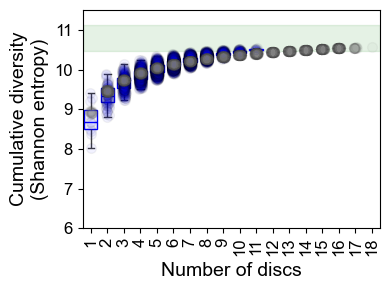

In [8]:
# Create a new figure for the plot
plt.figure(figsize=[4, 3])
df_shannonbray_data = pd.read_csv('Figurewise raw data/Supplementary figure 6.csv', index_col=0)
df_shannonbray_sim =pd.read_csv('Figurewise raw data/Supplementary figure sim 6.csv', index_col=0)

sns.stripplot(
    x='No_discs', y='Shannon', data=df_shannonbray_data,
    color='blue', alpha=0.05, s=7,
    edgecolor='black', linewidth=1, rasterized = True, label=''
)

sns.stripplot(
    x='No_discs', y='Shannon', data=df_shannonbray_sim,
    color='gray', alpha=0.05, s=7,
    edgecolor='gray', linewidth=1, rasterized = True, label=''
)

# Draw red boxplots for the disc data
sns.boxplot(
    x='No_discs', y='Shannon', data=df_shannonbray_data,
    boxprops=dict(facecolor='white', edgecolor='blue'),
    medianprops=dict(color='blue')
)

# Highlight the variance in the initial data to identify when the diversity deviates from initial
plt.axhspan(
    10.8 - 2.52*0.13,
    10.8 + 2.52*0.13,
    color='green', alpha=0.1
)

#plt.ylim([5,12])  # Optional: to set y-axis limits
plt.xlabel('Number of discs', fontname='Arial', fontsize=14)
plt.ylabel('Cumulative diversity\n(Shannon entropy)', fontname='arial', fontsize=14)

# Custom tick labels for time points
plt.xticks(fontname='Arial', fontsize=12, rotation = 90)
plt.yticks(fontname='Arial', fontsize=12)

plt.ylim([6,11.5])
plt.tight_layout()

plt.savefig('Figures paper/Shannon_cumulativebiofilm.svg', format='svg', dpi=300)


C:\Users\achoudhu\AppData\Local\Temp\ipykernel_3652\1260085881.py:12: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


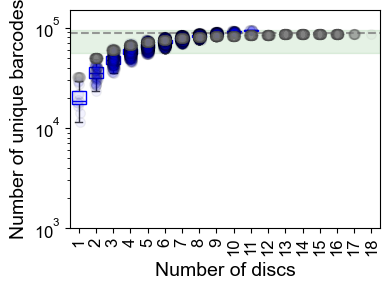

In [9]:
# Create a new figure for the plot
plt.figure(figsize=[4, 3])
df_shannonbray_data = pd.read_csv('Figurewise raw data/Supplementary figure 6.csv', index_col=0)
df_shannonbray_sim =pd.read_csv('Figurewise raw data/Supplementary figure sim 6.csv', index_col=0)

sns.stripplot(
    x='No_discs', y='Nb', data=df_shannonbray_data,
    color='blue', alpha=0.05, s=7,
    edgecolor='black', linewidth=1, rasterized = True, label=''
)

sns.stripplot(
    x='No_discs', y='Nb', data=df_shannonbray_sim,
    color='gray', alpha=0.05, s=7,
    edgecolor='gray', linewidth=1, rasterized = True, label=''
)

# Draw red boxplots for the disc data
sns.boxplot(
    x='No_discs', y='Nb', data=df_shannonbray_data,
    boxprops=dict(facecolor='white', edgecolor='blue'),
    medianprops=dict(color='blue')
)

# Highlight the variance in the initial data to identify when the diversity deviates from initial

plt.axhspan(
    75326 - 2.52*7901,
    75326 + 2.52*7901,
    color='green', alpha=0.1
)

plt.axhline(y = len(df_biofilm_filtered.loc[df_biofilm_filtered['3'] > 0]),\
            color = 'gray', linestyle = '--', label = 'Donor', alpha = 0.8)

#plt.ylim([5,12])  # Optional: to set y-axis limits
plt.xlabel('Number of discs', fontname='Arial', fontsize=14)
plt.ylabel('Number of unique barcodes', fontname='arial', fontsize=14)

# Custom tick labels for time points
plt.xticks(fontname='Arial', fontsize=12, rotation = 90)
plt.yticks(fontname='Arial', fontsize=12)

plt.yscale('log')
plt.ylim([10**3,1.5*10**5])

plt.tight_layout()

plt.savefig('Figures paper/NB_cumulativebiofilm.svg', format='svg', dpi=300)


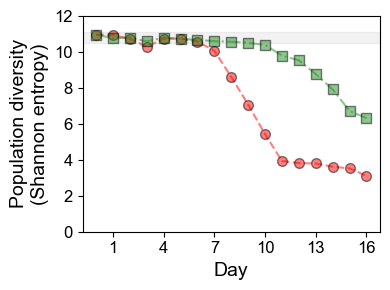

In [8]:
# Create a new figure for the plot
plt.figure(figsize=[4, 3])

# Convert the Shannon entropy values for BiofilmPlank_A into long format:
# - Transpose, stack into a long vector, then reset and rename columns.
df_data = pd.DataFrame(df_Shannon_Combined[['BiofilmPlank_A']].T.stack())\
    .reset_index()\
    .rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

# Add individual Shannon data as gray points
sns.stripplot(
    x='Day', y='Shannon', data=df_data,
    color='red', alpha=0.5, s=7,
    edgecolor='black', linewidth=1, label=''
)

# Add a dashed gray trend line across time for BiofilmPlank_A
plt.plot(
    df_Shannon_Combined.BiofilmPlank_A, '--',
    color='red', alpha=0.5,
    markersize=5, markeredgecolor='black'
)


# Convert the Shannon entropy values for BiofilmPlank_B into long-format:
# - Transpose the row, stack into a single column, reset index, rename columns
df_data = pd.DataFrame(df_Shannon_Combined[['BiofilmPlank_B']].T.stack())\
    .reset_index()\
    .rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

# Add gray individual data points (stripplot)
sns.stripplot(
    x='Day', y='Shannon', data=df_data,
    color='forestgreen', alpha=0.5, s=7,marker = 's',
    edgecolor='black', linewidth=1, label=''
)

# Add dashed gray line representing the temporal trend of BiofilmPlank_B
plt.plot(
    df_Shannon_Combined.BiofilmPlank_B, '-.',
    color='forestgreen', alpha=0.5, 
    markersize=5, markeredgecolor='black'
)

#plt.ylim([5,12])  # Optional: to set y-axis limits
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Population diversity\n(Shannon entropy)', fontname='arial', fontsize=14)

# Custom tick labels for time points
plt.xticks([1, 4, 7, 10, 13, 16], fontname='Arial', fontsize=12);
plt.yticks(fontname='Arial', fontsize=12);

# Highlight the variance in the initial data to identify when the diversity deviates from initial
plt.axhspan(
    10.8 - 2.52*0.13,
    10.8 + 2.52*0.13,
    color='gray', alpha=0.1
)

plt.ylim([0,12])
plt.tight_layout()
plt.savefig('Figures paper/WellAB_Plk_Shannon_Entropy.svg', format='svg', dpi=300)

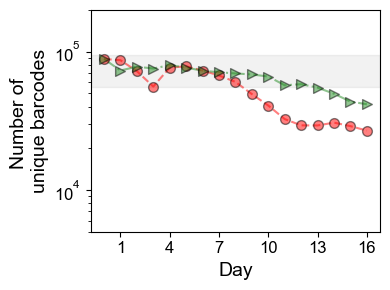

In [9]:
# Create a new figure for the plot
plt.figure(figsize=[4, 3])
# Convert the Shannon entropy values for BiofilmPlank_A into long format:
# - Transpose, stack into a long vector, then reset and rename columns.
df_data = pd.DataFrame(df_nbdiscs_Combined[['BiofilmPlank_A']].T.stack())\
    .reset_index()\
    .rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

# Add individual Shannon data as gray points
sns.stripplot(
    x='Day', y='Shannon', data=df_data,
    color='red', alpha=0.5, s=7,
    edgecolor='black', linewidth=1, label=''
)

# Add a dashed gray trend line across time for BiofilmPlank_A
plt.plot(
    df_nbdiscs_Combined.BiofilmPlank_A, '--',
    color='red', alpha=0.5,
    markersize=5, markeredgecolor='black'
)


# Convert the Shannon entropy values for BiofilmPlank_B into long-format:
# - Transpose the row, stack into a single column, reset index, rename columns
df_data = pd.DataFrame(df_nbdiscs_Combined[['BiofilmPlank_B']].T.stack())\
    .reset_index()\
    .rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

# Add gray individual data points (stripplot)
sns.stripplot(
    x='Day', y='Shannon', data=df_data,
    color='forestgreen', alpha=0.5, s=7,marker = '>',
    edgecolor='black', linewidth=1, label=''
)

# Add dashed gray line representing the temporal trend of BiofilmPlank_B
plt.plot(
    df_nbdiscs_Combined.BiofilmPlank_B, '-.',
    color='forestgreen', alpha=0.5, 
    markersize=5, markeredgecolor='black'
)

#plt.ylim([5,12])  # Optional: to set y-axis limits
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Number of \nunique barcodes', fontname='arial', fontsize=14)

# Custom tick labels for time points
plt.xticks([1, 4, 7, 10, 13, 16], fontname='Arial', fontsize=12);
plt.yticks(fontname='Arial', fontsize=12);

# Highlight the variance in the initial data to identify when the diversity deviates from initial
plt.axhspan(
    75326 - 2.52*7901,
    75326 + 2.52*7901,
    color='gray', alpha=0.1
)

plt.ylim([5000,200000])
plt.yscale('log')
plt.tight_layout()
plt.savefig('Figures paper/WellAB_Plk_Nb.svg', format='svg', dpi=300)

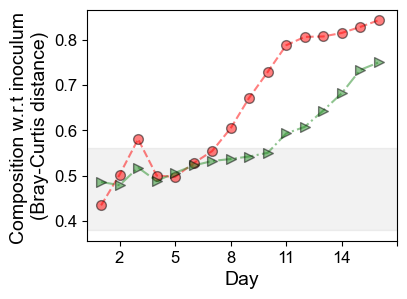

In [10]:
# Create a new figure for the plot
plt.figure(figsize=[4, 3])

# Convert the Shannon entropy values for BiofilmPlank_A into long format:
# - Transpose, stack into a long vector, then reset and rename columns.
df_data = pd.DataFrame(df_braycurtis_Combined[['BiofilmPlank_A']].T.stack())\
    .reset_index()\
    .rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

# Add individual Shannon data as gray points
sns.stripplot(
    x='Day', y='Shannon', data=df_data,
    color='red', alpha=0.5, s=7,
    edgecolor='black', linewidth=1, label=''
)

# Add a dashed gray trend line across time for BiofilmPlank_A
plt.plot(df_braycurtis_Combined.index-1,
    df_braycurtis_Combined.BiofilmPlank_A, '--',
    color='red', alpha=0.5,
    markersize=5, markeredgecolor='black'
)

# Convert the Shannon entropy values for BiofilmPlank_B into long-format:
# - Transpose the row, stack into a single column, reset index, rename columns
df_data = pd.DataFrame(df_braycurtis_Combined[['BiofilmPlank_B']].T.stack())\
    .reset_index()\
    .rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

# Add gray individual data points (stripplot)
sns.stripplot(
    x='Day', y='Shannon', data=df_data,
    color='forestgreen', alpha=0.5, s=7,marker = '>',
    edgecolor='black', linewidth=1, label=''
)


# Add dashed gray line representing the temporal trend of BiofilmPlank_B
plt.plot(df_braycurtis_Combined.index-1,
    df_braycurtis_Combined.BiofilmPlank_B, '-.',
    color='forestgreen', alpha=0.5, 
    markersize=5, markeredgecolor='black'
)

# Highlight inoculum baseline (± 2.52 SD)
plt.axhspan(0.47-2.52*0.036, 0.47+2.52*0.036, color = 'gray', alpha = 0.1)

#plt.ylim([5,12])  # Optional: to set y-axis limits
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Composition w.r.t inoculum \n(Bray-Curtis distance)', fontname='arial', fontsize=14)

# Custom tick labels for time points
plt.xticks([1, 4, 7, 10, 13, 16], fontname='Arial', fontsize=12);
plt.yticks(fontname='Arial', fontsize=12);

# Save the figure as an SVG for publication-quality output
plt.savefig('Figures paper/WellAB_Plk_BrayCurtis.svg', format='svg', dpi=300)

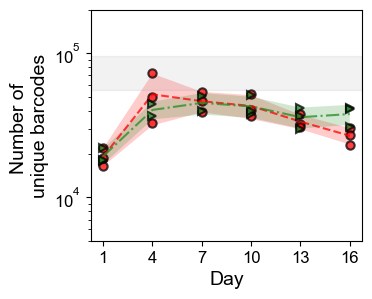

In [11]:
# Create a new figure for the plot
plt.figure(figsize=[3.5, 3])

# Prepare Disc_A1, Disc_A2, Disc_A3 Shannon values:
# - Drop NaN rows, transpose, stack, convert to long format.
df_data = pd.DataFrame(
    df_nbdiscs_Combined[['Disc_A1', 'Disc_A2', 'Disc_A3']].dropna().T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})
df_data_A = df_data
df_data_A['Replicate'] = 'A'

for discname in ['Disc_A1', 'Disc_A2', 'Disc_A3']:
    plt.plot(df_data_A.loc[df_data_A.Disc == discname].Day,\
             df_data_A.loc[df_data_A.Disc == discname].Shannon, 'o',\
             color = 'red',alpha = 0.75,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

# 1. Calculate Mean and Standard Deviation
stats_A = df_data_A.groupby('Day')['Shannon'].agg(['mean', 'std']).reset_index()

# 2. Plot the shaded area (Mean +/- 1 Standard Deviation)
plt.fill_between(
    stats_A.Day, 
    stats_A['mean'] - stats_A['std'], 
    stats_A['mean'] + stats_A['std'], 
    color='red', 
    alpha=0.2,       # Low alpha makes it a light "mist"
    edgecolor='none' # Removes the harsh outline around the shaded box
)

# 3. Plot the mean line (as you already have)
plt.plot(stats_A.Day, stats_A['mean'], color='red', linestyle='--', alpha=0.75)

# --- Plot 2: Red boxplots/points/mean line for Disc A1–A3 ---

# Prepare Disc_B1, Disc_B2, Disc_B3 Shannon values:
# - Drop NaN rows, transpose, stack, convert to long format.
# Extract disc-level Shannon data (B1, B2, B3)
df_data = df_nbdiscs_Combined[['Disc_B1', 'Disc_B2', 'Disc_B3']]

# Remove any rows where Disc_B2 is NaN (to keep the dataset aligned)
df_data = df_data.loc[pd.isna(df_data.Disc_B2) == False]

# Convert disc data into long-format (stacked)
df_data = pd.DataFrame(
    df_data[['Disc_B1', 'Disc_B2', 'Disc_B3']].T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

df_data_B = df_data
df_data_B.loc[1,'Shannon'] = np.nan
df_data_B = df_data_B.dropna()

for discname in ['Disc_B1', 'Disc_B2', 'Disc_B3']:
    plt.plot(df_data_B.loc[df_data_B.Disc == discname].Day,\
             df_data_B.loc[df_data_B.Disc == discname].Shannon, '>',\
             color = 'forestgreen',alpha = 0.75,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

# 1. Calculate Mean and Standard Deviation
stats_B = df_data_B.groupby('Day')['Shannon'].agg(['mean', 'std']).reset_index()

# 2. Plot the shaded area (Mean +/- 1 Standard Deviation)
plt.fill_between(
    stats_B.Day, 
    stats_B['mean'] - stats_B['std'], 
    stats_B['mean'] + stats_B['std'], 
    color='forestgreen', 
    alpha=0.2,       # Low alpha makes it a light "mist"
    edgecolor='none' # Removes the harsh outline around the shaded box
)

# 3. Plot the mean line (as you already have)
plt.plot(stats_B.Day, stats_B['mean'], color='forestgreen', linestyle='-.', alpha=0.75)

#plt.ylim([5,12])  # Optional manual y-axis limit
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Number of \nunique barcodes', fontname='arial', fontsize=14)

# Custom x-axis tick positions
plt.xticks([1, 4, 7, 10, 13, 16], fontname='Arial', fontsize=12)
plt.yticks(fontname='Arial', fontsize=12)

plt.axhspan(
    75326 - 2.52*7901,
    75326 + 2.52*7901,
    color='gray', alpha=0.1
)

plt.ylim([5000,200000])
plt.yscale('log')

plt.savefig('Figures paper/WellA_Dsc_Nb.svg', format='svg', dpi=300)


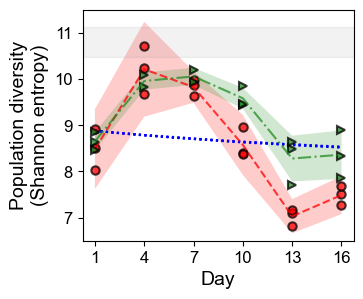

In [12]:
# Create a new figure for the plot
plt.figure(figsize=[3.5, 3])

#--- Plot 0: Simulated data for how the population dynamics should look like ---
df_simulation = pd.read_csv('Simulation_final/Temp/Shannon_all.csv')

for replicate in range(10):
    df = df_simulation.loc[(df_simulation.migration_rate == 0) & (df_simulation.replicate == replicate)]
    
    plt.plot(df.cycle+1, df.Disc,':', color = 'blue', alpha = 0.5, label = '')

# Convert the Shannon entropy values for BiofilmPlank_A into long format:
# - Transpose, stack into a long vector, then reset and rename columns.


# --- Plot 2: Red boxplots/points/mean line for Disc A1–A3 ---

# Prepare Disc_A1, Disc_A2, Disc_A3 Shannon values:
# - Drop NaN rows, transpose, stack, convert to long format.
df_data = pd.DataFrame(
    df_Shannon_Combined[['Disc_A1', 'Disc_A2', 'Disc_A3']].dropna().T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})
df_data_A = df_data
df_data_A['Replicate'] = 'A'

for discname in ['Disc_A1', 'Disc_A2', 'Disc_A3']:
    plt.plot(df_data_A.loc[df_data_A.Disc == discname].Day,\
             df_data_A.loc[df_data_A.Disc == discname].Shannon, 'o',\
             color = 'red',alpha = 0.75,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

# 1. Calculate Mean and Standard Deviation
stats_A = df_data_A.groupby('Day')['Shannon'].agg(['mean', 'std']).reset_index()

# 2. Plot the shaded area (Mean +/- 1 Standard Deviation)
plt.fill_between(
    stats_A.Day, 
    stats_A['mean'] - 1.96*stats_A['std'], 
    stats_A['mean'] + 1.96*stats_A['std'], 
    color='red', 
    alpha=0.2,       # Low alpha makes it a light "mist"
    edgecolor='none' # Removes the harsh outline around the shaded box
)

# 3. Plot the mean line (as you already have)
plt.plot(stats_A.Day, stats_A['mean'], color='red', linestyle='--', alpha=0.75)


# --- Plot 2: Red boxplots/points/mean line for Disc A1–A3 ---

# Prepare Disc_B1, Disc_B2, Disc_B3 Shannon values:
# - Drop NaN rows, transpose, stack, convert to long format.
# Extract disc-level Shannon data (B1, B2, B3)
df_data = df_Shannon_Combined[['Disc_B1', 'Disc_B2', 'Disc_B3']]

# Remove any rows where Disc_B2 is NaN (to keep the dataset aligned)
df_data = df_data.loc[pd.isna(df_data.Disc_B2) == False]

# Convert disc data into long-format (stacked)
df_data = pd.DataFrame(
    df_data[['Disc_B1', 'Disc_B2', 'Disc_B3']].T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

df_data_B = df_data
df_data_B.loc[1,'Shannon'] = np.nan
df_data_B = df_data_B.dropna()

for discname in ['Disc_B1', 'Disc_B2', 'Disc_B3']:
    plt.plot(df_data_B.loc[df_data_B.Disc == discname].Day,\
             df_data_B.loc[df_data_B.Disc == discname].Shannon, '>',\
             color = 'forestgreen',alpha = 0.75,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

# 1. Calculate Mean and Standard Deviation
stats_B = df_data_B.groupby('Day')['Shannon'].agg(['mean', 'std']).reset_index()

# 2. Plot the shaded area (Mean +/- 1 Standard Deviation)
plt.fill_between(
    stats_B.Day, 
    stats_B['mean'] - stats_B['std'], 
    stats_B['mean'] + stats_B['std'], 
    color='forestgreen', 
    alpha=0.2,       # Low alpha makes it a light "mist"
    edgecolor='none' # Removes the harsh outline around the shaded box
)

# 3. Plot the mean line (as you already have)
plt.plot(stats_B.Day, stats_B['mean'], color='forestgreen', linestyle='-.', alpha=0.75)

#plt.ylim([5,12])  # Optional manual y-axis limit
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Population diversity\n(Shannon entropy)', fontname='arial', fontsize=14)

# Custom x-axis tick positions
plt.xticks([1, 4, 7, 10, 13, 16], fontname='Arial', fontsize=12)
plt.yticks(fontname='Arial', fontsize=12)

# Highlight the variance in the initial data to identify when the diversity deviates from initial
plt.axhspan(
    10.8 - 2.52*0.13,
    10.8 + 2.52*0.13,
    color='gray', alpha=0.1
)

plt.ylim([6.5,11.5])

plt.savefig('Figures paper/WellA_Dsc_Shannon_Entropy.svg', format='svg', dpi=300)


In [13]:
df_simulation = pd.read_csv('Simulation_final/Temp/Shannon_all.csv')
df_simulation.to_csv('Figurewise raw data/3F.Simulation_Shannon.csv')

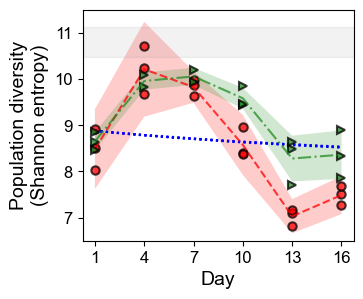

In [14]:
# Create a new figure for the plot
plt.figure(figsize=[3.5, 3])

#--- Plot 0: Simulated data for how the population dynamics should look like ---
df_simulation = pd.read_csv('Simulation_final/Temp/Shannon_all.csv')

for replicate in range(10):
    df = df_simulation.loc[(df_simulation.migration_rate == 0) & (df_simulation.replicate == replicate)]
    
    plt.plot(df.cycle+1, df.Disc,':', color = 'blue', alpha = 0.5, label = '')

# Convert the Shannon entropy values for BiofilmPlank_A into long format:
# - Transpose, stack into a long vector, then reset and rename columns.


# --- Plot 2: Red boxplots/points/mean line for Disc A1–A3 ---

# Prepare Disc_A1, Disc_A2, Disc_A3 Shannon values:
# - Drop NaN rows, transpose, stack, convert to long format.
df_data = pd.DataFrame(
    df_Shannon_Combined[['Disc_A1', 'Disc_A2', 'Disc_A3']].dropna().T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})
df_data_A = df_data
df_data_A['Replicate'] = 'A'

for discname in ['Disc_A1', 'Disc_A2', 'Disc_A3']:
    plt.plot(df_data_A.loc[df_data_A.Disc == discname].Day,\
             df_data_A.loc[df_data_A.Disc == discname].Shannon, 'o',\
             color = 'red',alpha = 0.75,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

# 1. Calculate Mean and Standard Deviation
stats_A = df_data_A.groupby('Day')['Shannon'].agg(['mean', 'std']).reset_index()

# 2. Plot the shaded area (Mean +/- 1 Standard Deviation)
plt.fill_between(
    stats_A.Day, 
    stats_A['mean'] - 1.96*stats_A['std'], 
    stats_A['mean'] + 1.96*stats_A['std'], 
    color='red', 
    alpha=0.2,       # Low alpha makes it a light "mist"
    edgecolor='none' # Removes the harsh outline around the shaded box
)

# 3. Plot the mean line (as you already have)
plt.plot(stats_A.Day, stats_A['mean'], color='red', linestyle='--', alpha=0.75)


# --- Plot 2: Red boxplots/points/mean line for Disc A1–A3 ---

# Prepare Disc_B1, Disc_B2, Disc_B3 Shannon values:
# - Drop NaN rows, transpose, stack, convert to long format.
# Extract disc-level Shannon data (B1, B2, B3)
df_data = df_Shannon_Combined[['Disc_B1', 'Disc_B2', 'Disc_B3']]

# Remove any rows where Disc_B2 is NaN (to keep the dataset aligned)
df_data = df_data.loc[pd.isna(df_data.Disc_B2) == False]

# Convert disc data into long-format (stacked)
df_data = pd.DataFrame(
    df_data[['Disc_B1', 'Disc_B2', 'Disc_B3']].T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

df_data_B = df_data
df_data_B.loc[1,'Shannon'] = np.nan
df_data_B = df_data_B.dropna()

for discname in ['Disc_B1', 'Disc_B2', 'Disc_B3']:
    plt.plot(df_data_B.loc[df_data_B.Disc == discname].Day,\
             df_data_B.loc[df_data_B.Disc == discname].Shannon, '>',\
             color = 'forestgreen',alpha = 0.75,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

# 1. Calculate Mean and Standard Deviation
stats_B = df_data_B.groupby('Day')['Shannon'].agg(['mean', 'std']).reset_index()

# 2. Plot the shaded area (Mean +/- 1 Standard Deviation)
plt.fill_between(
    stats_B.Day, 
    stats_B['mean'] - stats_B['std'], 
    stats_B['mean'] + stats_B['std'], 
    color='forestgreen', 
    alpha=0.2,       # Low alpha makes it a light "mist"
    edgecolor='none' # Removes the harsh outline around the shaded box
)

# 3. Plot the mean line (as you already have)
plt.plot(stats_B.Day, stats_B['mean'], color='forestgreen', linestyle='-.', alpha=0.75)

#plt.ylim([5,12])  # Optional manual y-axis limit
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Population diversity\n(Shannon entropy)', fontname='arial', fontsize=14)

# Custom x-axis tick positions
plt.xticks([1, 4, 7, 10, 13, 16], fontname='Arial', fontsize=12)
plt.yticks(fontname='Arial', fontsize=12)

# Highlight the variance in the initial data to identify when the diversity deviates from initial
plt.axhspan(
    10.8 - 2.52*0.13,
    10.8 + 2.52*0.13,
    color='gray', alpha=0.1
)

plt.ylim([6.5,11.5])

plt.savefig('Figures paper/WellA_Dsc_Shannon_Entropy.svg', format='svg', dpi=300)


In [15]:
import scipy.stats as stats
print(stats.ttest_ind(df_data.loc[df_data.Day == 1].Shannon, \
                      df_data.loc[df_data.Day == 4].Shannon))

print(stats.ttest_ind(df_data.loc[df_data.Day == 1].Shannon, \
                      df_data.loc[df_data.Day == 7].Shannon))

print(stats.ttest_ind(df_data.loc[df_data.Day == 1].Shannon, \
                      df_data.loc[df_data.Day == 10].Shannon))

print(stats.ttest_ind(df_data.loc[df_data.Day == 10].Shannon, \
                      df_data.loc[df_data.Day == 13].Shannon))

print(stats.ttest_ind(df_data.loc[df_data.Day == 10].Shannon, \
                      df_data.loc[df_data.Day == 16].Shannon))

TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))
TtestResult(statistic=np.float64(-7.894382772466141), pvalue=np.float64(0.004236246985949197), df=np.float64(3.0))
TtestResult(statistic=np.float64(-5.345878855824584), pvalue=np.float64(0.005901941577067575), df=np.float64(4.0))
TtestResult(statistic=np.float64(4.153433323577351), pvalue=np.float64(0.014220637373008275), df=np.float64(4.0))
TtestResult(statistic=np.float64(3.694432883685533), pvalue=np.float64(0.020937238720461722), df=np.float64(4.0))


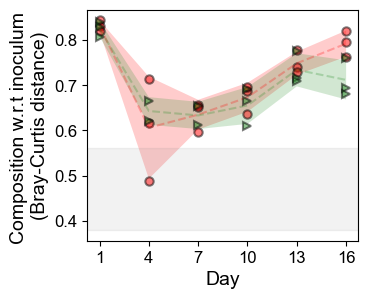

In [16]:
# Create a new figure for the plot
plt.figure(figsize=[3.5, 3])

# Convert the Shannon entropy values for BiofilmPlank_A into long format:
# - Transpose, stack into a long vector, then reset and rename columns.


# --- Plot 2: Red boxplots/points/mean line for Disc A1–A3 ---

# Prepare Disc_A1, Disc_A2, Disc_A3 Shannon values:
# - Drop NaN rows, transpose, stack, convert to long format.
df_data = pd.DataFrame(
    df_braycurtis_Combined[['Disc_A1', 'Disc_A2', 'Disc_A3']].dropna().T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})
df_data_A = df_data
df_data_A['Replicate'] = 'A'

for discname in ['Disc_A1', 'Disc_A2', 'Disc_A3']:
    plt.plot(df_data_A.loc[df_data_A.Disc == discname].Day,\
             df_data_A.loc[df_data_A.Disc == discname].Shannon, 'o',\
             color = 'red',alpha = 0.5,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

# 1. Calculate Mean and Standard Deviation
stats_A = df_data_A.groupby('Day')['Shannon'].agg(['mean', 'std']).reset_index()

# 2. Plot the shaded area (Mean +/- 1 Standard Deviation)
plt.fill_between(
    stats_A.Day, 
    stats_A['mean'] - stats_A['std'], 
    stats_A['mean'] + stats_A['std'], 
    color='red', 
    alpha=0.2,       # Low alpha makes it a light "mist"
    edgecolor='none' # Removes the harsh outline around the shaded box
)

# 3. Plot the mean line (as you already have)
plt.plot(stats_A.Day, stats_A['mean'], color='red', linestyle='--', alpha=0.25)

df_data = df_braycurtis_Combined[['Disc_B1', 'Disc_B2', 'Disc_B3']]

# Remove any rows where Disc_B2 is NaN (to keep the dataset aligned)
df_data = df_data.loc[pd.isna(df_data.Disc_B2) == False]

# Convert disc data into long-format (stacked)
df_data = pd.DataFrame(
    df_data[['Disc_B1', 'Disc_B2', 'Disc_B3']].T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

df_data_B = df_data
df_data_B.loc[1,'Shannon'] = np.nan
df_data_B = df_data_B.dropna()

for discname in ['Disc_B1', 'Disc_B2', 'Disc_B3']:
    plt.plot(df_data_B.loc[df_data_B.Disc == discname].Day,\
             df_data_B.loc[df_data_B.Disc == discname].Shannon, '>',\
             color = 'forestgreen',alpha = 0.5,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

# 1. Calculate Mean and Standard Deviation
stats_B = df_data_B.groupby('Day')['Shannon'].agg(['mean', 'std']).reset_index()

# 2. Plot the shaded area (Mean +/- 1 Standard Deviation)
plt.fill_between(
    stats_B.Day, 
    stats_B['mean'] - stats_B['std'], 
    stats_B['mean'] + stats_B['std'], 
    color='forestgreen', 
    alpha=0.2,       # Low alpha makes it a light "mist"
    edgecolor='none' # Removes the harsh outline around the shaded box
)

# 3. Plot the mean line (as you already have)
plt.plot(stats_B.Day, stats_B['mean'], color='forestgreen', linestyle='--', alpha=0.25)


#plt.ylim([5,12])  # Optional manual y-axis limit
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Composition w.r.t inoculum \n(Bray-Curtis distance)', fontname='arial', fontsize=14)

# Custom x-axis tick positions
plt.xticks([1, 4, 7, 10, 13, 16], fontname='Arial', fontsize=12)
plt.yticks(fontname='Arial', fontsize=12)

#plt.ylim([6.5,11.5])

# Highlight inoculum baseline (± 2.52 SD)
plt.axhspan(0.47-2.52*0.036, 0.47+2.52*0.036, color = 'gray', alpha = 0.1)

plt.savefig('Figures paper/WellA_Dsc_BrayCurtis.svg', format='svg', dpi=300)


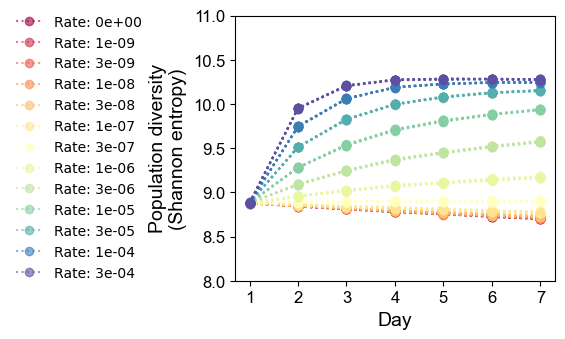

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Create a new figure - slightly wider to accommodate left legend
plt.figure(figsize=[6, 3.5])

unique_rates = df_simulation.migration_rate.drop_duplicates().sort_values()
num_rates = len(unique_rates)
cmap = plt.get_cmap('Spectral') 

for i, rate in enumerate(unique_rates):
    line_color = cmap(i / (num_rates - 1)) if num_rates > 1 else cmap(0.5)
    df_rate = df_simulation[df_simulation.migration_rate == rate]
    
    for replicate in df_rate.replicate.unique():
        df = df_rate[df_rate.replicate == replicate]
        df = df.loc[df.cycle < 7]
        
        # Formatting
        formatted_rate = f"{rate:.0e}" 
        label = f'Rate: {formatted_rate}' if replicate == 0 else ""
        
        plt.plot(df.cycle + 1, df.Disc, 'o:', color=line_color, 
                 alpha=0.6, label=label) # Lowered alpha slightly for better visibility of overlaps

plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Population diversity\n(Shannon entropy)', fontname='Arial', fontsize=14)
plt.ylim([8, 11])

# Custom x-axis tick positions
plt.xticks(fontname='Arial', fontsize=12);
plt.yticks(fontname='Arial', fontsize=12);

# --- LEGEND ON THE LEFT ---
plt.legend(bbox_to_anchor=(-0.25, 1.05), loc='upper right', frameon=False, fontsize=10)

# Adjust the plot area so the legend on the left is visible
# Increase 'left' value if your legend labels are very long
plt.subplots_adjust(left=0.25, right=0.95)
plt.tight_layout()
plt.savefig('Figures paper/Shannon_Left_Legend.svg', format='svg')
plt.show()

In [19]:
df_simulation.to_csv('Figurewise raw data/3F-3G Migration Simulation.csv')

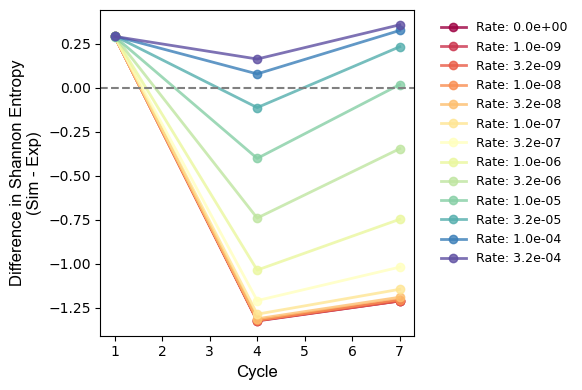

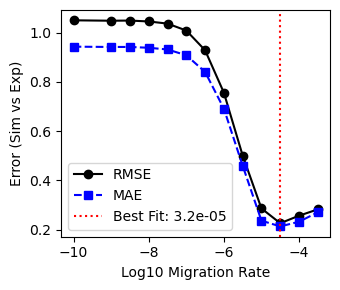

In [21]:

unique_rates = df_simulation.migration_rate.drop_duplicates().sort_values()
num_rates = len(unique_rates)
cmap = plt.get_cmap('Spectral') # Using a drastic/high-contrast map

plt.figure(figsize=[6, 4])

results = []


for i, rate in enumerate(unique_rates):
    # ... [Keep your data processing code here] ...
    # 1. Define the color for this specific rate
    line_color = cmap(i / (num_rates - 1)) if num_rates > 1 else cmap(0.5)
    
    # 2. Process Experimental Data (Baseline)
    df_mean_shannon = pd.DataFrame(df_Shannon_Combined[['Disc_A1','Disc_A2','Disc_A3','Disc_B2','Disc_B3']]
                     .dropna().mean(axis=1)).reset_index().rename(columns={'index':'Day', 0:'Mean_Shannon'})
    df_mean_shannon = df_mean_shannon.loc[df_mean_shannon.Day <= 7]
    df_mean_shannon['Day'] = df_mean_shannon['Day'] - 1
    df_mean_shannon = df_mean_shannon.set_index('Day').rename(columns={'Mean_Shannon':'Disc'})
    
    # 3. Process Simulation Data
    df_rate = df_simulation[df_simulation.migration_rate == rate]
    
    # Selecting specific cycles: 0, 3, and 6
    sim_means = df_rate[['cycle','Disc']].groupby('cycle').mean()
    df_mean_simulation = sim_means.loc[[0, 3, 6]]
    
    # 4. Calculate Difference
    # Ensure indices match for subtraction
    difference = df_mean_simulation['Disc'] - df_mean_shannon['Disc']
    
    # 5. Define the Label correctly
    # Use the rate variable directly from the loop
    label = f'Rate: {rate:.1e}' 

    # 6. Plot
    # 6. Plot
    plt.plot(difference.index + 1, difference, '-o', color=line_color, 
             alpha=0.8, linewidth=2, label=label)
    mean_difference.append(difference.mean())
    
    # Ensure we are comparing the exact same points
    sim_values = df_mean_simulation['Disc'].values
    exp_values = df_mean_shannon['Disc'].values
    
    # Calculate Metrics
    mse = np.mean((sim_values - exp_values)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(sim_values - exp_values))
    
    results.append({
        'rate': rate,
        'log_rate': np.log10(rate) if rate > 0 else -10,
        'RMSE': rmse,
        'MAE': mae
    })

plt.xlabel('Cycle', fontname='Arial', fontsize=12)
plt.ylabel('Difference in Shannon Entropy\n(Sim - Exp)', fontname='Arial', fontsize=12)

# Now the legend will find the 'label' assigned in plt.plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()

plt.axhline(y = 0, linestyle = '--', color = 'gray')

plt.show()

# Convert to DataFrame for easy plotting
df_metrics = pd.DataFrame(results)

# --- Plot the Justification Curve ---
plt.figure(figsize=[3.5, 3])
plt.plot(df_metrics.log_rate, df_metrics.RMSE, '-o', color='black', label='RMSE')
plt.plot(df_metrics.log_rate, df_metrics.MAE, '--s', color='blue', label='MAE')

# Identify the best rate
best_row = df_metrics.loc[df_metrics.RMSE.idxmin()]
plt.axvline(best_row.log_rate, color='red', linestyle=':', label=f'Best Fit: {best_row.rate:.1e}')

plt.xlabel('Log10 Migration Rate')
plt.ylabel('Error (Sim vs Exp)')

plt.legend()
plt.tight_layout()
plt.savefig('Figures paper/Temporal parameter optimisation.svg', format='svg')
plt.show()

In [22]:
#Print the results for the best row
best_row

rate        0.000032
log_rate   -4.500000
RMSE        0.226455
MAE         0.213480
Name: 10, dtype: float64

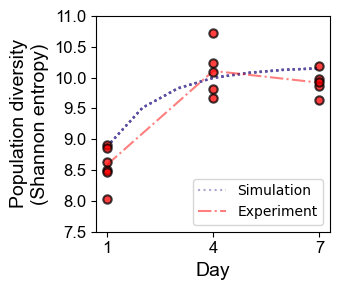

In [23]:

#--- Plot 0: Simulated data for how the population dynamics should look like ---
df_simulation = pd.read_csv('Simulation_final/Temp/Shannon_all.csv')

import matplotlib.pyplot as plt
import numpy as np

# Create a new figure
plt.figure(figsize=[3.5, 3])

# Filter data for this rate
df_rate = df_simulation[df_simulation.migration_rate == best_row.rate]
    
for replicate in df_rate.replicate.unique():
    df = df_rate[df_rate.replicate == replicate]
    df = df.loc[df.cycle < 7]
    # --- THE FORMATTING FIX ---
    # Format the rate to 1 decimal place in scientific notation
    formatted_rate = f"{rate:.1e}" 
        
    # Only label the first replicate so the legend stays clean
    label = f'Rate: {formatted_rate}' if replicate == 0 else ""
    if replicate == 0:  
        plt.plot(df.cycle + 1, df.Disc, ':', color=line_color, 
                     alpha=0.5, label='Simulation')
    else:
        plt.plot(df.cycle + 1, df.Disc, ':', color=line_color, 
                     alpha=0.5, label='')

plt.xlabel('Cycle', fontname='Arial', fontsize=12)
plt.ylabel('Disc Shannon Entropy', fontname='Arial', fontsize=12)

plt.tight_layout()

plt.plot(df_mean_shannon.index+1, df_mean_shannon, '-.', color = 'red', alpha = 0.5, label = 'Experiment')

df_data = pd.DataFrame(
    df_Shannon_Combined[['Disc_A1', 'Disc_A2', 'Disc_A3']].dropna().T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})
df_data_A = df_data
df_data_A['Replicate'] = 'A'

df_data_A = df_data_A.loc[df_data_A.Day <= 7]
for discname in ['Disc_A1', 'Disc_A2', 'Disc_A3']:
    plt.plot(df_data_A.loc[df_data_A.Disc == discname].Day,\
             df_data_A.loc[df_data_A.Disc == discname].Shannon, 'o',\
             color = 'red',alpha = 0.75,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

# Extract disc-level Shannon data (B1, B2, B3)
df_data = df_Shannon_Combined[['Disc_B1', 'Disc_B2', 'Disc_B3']]

# Remove any rows where Disc_B2 is NaN (to keep the dataset aligned)
df_data = df_data.loc[pd.isna(df_data.Disc_B2) == False]

df_data = pd.DataFrame(
    df_data[['Disc_B1', 'Disc_B2', 'Disc_B3']].T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

df_data_B = df_data
df_data_B.loc[1,'Shannon'] = np.nan
df_data_B = df_data_B.dropna()

df_data_B = df_data_B.loc[df_data_B.Day <= 7]

for discname in ['Disc_B1', 'Disc_B2', 'Disc_B3']:
    plt.plot(df_data_B.loc[df_data_B.Disc == discname].Day,\
             df_data_B.loc[df_data_B.Disc == discname].Shannon, 'o',\
             color = 'red',alpha = 0.75,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

plt.ylim([7.5,11])

#plt.ylim([5,12])  # Optional manual y-axis limit
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Population diversity\n(Shannon entropy)', fontname='arial', fontsize=14)

plt.legend()

# Custom x-axis tick positions
plt.xticks([1, 4, 7], fontname='Arial', fontsize=12);
plt.yticks(fontname='Arial', fontsize=12);

plt.tight_layout()
plt.savefig('Figures paper/Temporal bestfit.svg', format='svg')
plt.show()


In [17]:
# ------------------------------------------------------------
# CLEAN UNIFIED SCRIPT FOR CALCULATING BRAY–CURTIS DISTANCES
# BETWEEN DISCS (A1–A2, A2–A3, ..., A3–B3)
# ------------------------------------------------------------

# Helper function to compute Bray–Curtis distances between two lists of timepoints
def compute_bray_list(df, list1, list2):
    """
    Compute Bray–Curtis distance between matched timepoints
    across two discs or samples.
    NaN values are replaced with zero.
    """
    distances = []
    for t1, t2 in zip(list1, list2):
        distances.append(distance.braycurtis(
            df['t_' + t1 + '_f'].replace(np.nan, 0),
            df['t_' + t2 + '_f'].replace(np.nan, 0)
        ))
    return distances


# ------------------------------------------------------------
# TIMEPOINT DEFINITIONS FOR EACH DISC
# Each group contains six timepoints for that disc
# ------------------------------------------------------------
A1 = ['12','48','84','120','148','172']
A2 = ['13','49','85','121','149','173']
A3 = ['14','50','86','122','150','174']

B1 = ['15','51','87','123','151','175']
B2 = ['16','52','88','124','152','176']
B3 = ['17','53','89','125','153','177']


# ------------------------------------------------------------
# COMPUTE ALL REQUIRED DISC–DISC COMPARISONS
# ------------------------------------------------------------
df_braycurtis_disc = pd.DataFrame()

# Within-well comparisons (A)
df_braycurtis_disc['DiscA12'] = compute_bray_list(df_biofilm_filtered, A1, A2)
df_braycurtis_disc['DiscA23'] = compute_bray_list(df_biofilm_filtered, A2, A3)
df_braycurtis_disc['DiscA13'] = compute_bray_list(df_biofilm_filtered, A1, A3)

# Within-well comparisons (B)
df_braycurtis_disc['DiscB12'] = compute_bray_list(df_biofilm_filtered, B1, B2)
df_braycurtis_disc['DiscB23'] = compute_bray_list(df_biofilm_filtered, B2, B3)
df_braycurtis_disc['DiscB13'] = compute_bray_list(df_biofilm_filtered, B1, B3)

# Cross-well comparisons (A vs B)
df_braycurtis_disc['DiscA1B1'] = compute_bray_list(df_biofilm_filtered, A1, B1)
df_braycurtis_disc['DiscA2B2'] = compute_bray_list(df_biofilm_filtered, A2, B2)
df_braycurtis_disc['DiscA3B3'] = compute_bray_list(df_biofilm_filtered, A3, B3)


# ------------------------------------------------------------
# MANUAL ADJUSTMENT OF SPECIFIC TIMEPOINTS
# (Copied exactly from your original script)
# ------------------------------------------------------------
df_braycurtis_disc.loc[2, 'DiscB12'] = np.nan
df_braycurtis_disc.loc[2, 'DiscB13'] = np.nan
df_braycurtis_disc.loc[2, 'DiscA1B1'] = np.nan


# ------------------------------------------------------------
# SAVE TO FILE
# ------------------------------------------------------------
df_braycurtis_disc.to_excel(
    'Figurewise raw data/3E. Temporal Disc-Disc distance.xlsx'
)
df_braycurtis_disc

,DiscA12,DiscA23,DiscA13,DiscB12,DiscB23,DiscB13,DiscA1B1,DiscA2B2,DiscA3B3
0,0.900968,0.892536,0.904316,0.903488,0.890592,0.894816,0.912796,0.900416,0.882804
1,0.736096,0.596116,0.694348,0.801572,0.660284,0.790056,0.833088,0.672872,0.647076
2,0.630716,0.650676,0.676432,NaN,0.664964,NaN,NaN,0.652204,0.713984
3,0.634744,0.545388,0.606904,0.649412,0.624624,0.619888,0.717468,0.761284,0.663688
4,0.525028,0.516116,0.484248,0.628540,0.556416,0.629188,0.812160,0.811028,0.744068
5,0.644616,0.634088,0.694780,0.621860,0.638392,0.545704,0.815068,0.831040,0.830012


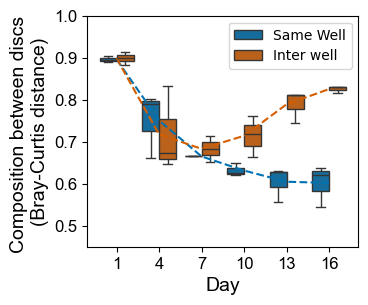

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the Bray–Curtis dataframe previously computed
df_Bray = df_braycurtis_disc

# Create a new figure for plotting
plt.figure(figsize=[3.5, 3])

# ------------------------------------------------------------
# Prepare SAME-WELL DISC comparisons (B1–B2, B2–B3, B1–B3)
# ------------------------------------------------------------

# Select Bray–Curtis distances for same-well comparisons
df_plot = df_Bray[['DiscB12','DiscB23','DiscB13']]

# Remove rows where DiscB23 is missing (ensures complete rows)
df_plot = df_plot.loc[pd.isna(df_plot.DiscB23) == False]

# Convert wide format → long format for plotting
df_data = pd.DataFrame(
    df_plot[['DiscB12','DiscB23','DiscB13']].T.stack()
).reset_index().rename(columns={'level_0':'Disc','level_1':'Day',0:'Bray'})

# Label these as “Same Well”
df_data['Sample'] = 'Same Well'

# ------------------------------------------------------------
# Prepare INTER-WELL DISC comparisons (A1–B1, A2–B2, A3–B3)
# ------------------------------------------------------------

df_plot2 = df_Bray[['DiscA1B1','DiscA2B2','DiscA3B3']]
df_plot2 = df_plot2.loc[pd.isna(df_plot2.DiscA2B2) == False]

# Wide → long format
df_data2 = pd.DataFrame(
    df_plot2[['DiscA1B1','DiscA2B2','DiscA3B3']].T.stack()
).reset_index().rename(columns={'level_0':'Disc','level_1':'Day',0:'Bray'})

# Label these as “Inter well”
df_data2['Sample'] = 'Inter well'

# Combine same-well and inter-well datasets
df_data3 = pd.concat([df_data, df_data2])

# ------------------------------------------------------------
# Plot boxplots comparing same-well vs inter-well Bray–Curtis
# ------------------------------------------------------------
sns.boxplot(
    x='Day', 
    y='Bray', 
    data=df_data3, 
    hue='Sample', 
    palette={"Same Well": "#0072B2", "Inter well": "#D55E00"}
)




# ------------------------------------------------------------
# Plot mean Bray–Curtis trend lines for each category
# ------------------------------------------------------------

# Mean across days for SAME-WELL
data = df_data[['Day','Bray']].groupby('Day').mean()
plt.plot([0,1,2,3,4,5], data.Bray, color='#0072B2', alpha=1, linestyle='--')

# Mean across days for INTER-WELL
data = df_data2[['Day','Bray']].groupby('Day').mean()
plt.plot([0,1,2,3,4,5], data.Bray, color='#D55E00', alpha=1, linestyle='--')

# ------------------------------------------------------------
# Formatting the figure
# ------------------------------------------------------------
plt.legend(ncol=1)

plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Composition between discs \n(Bray-Curtis distance)',
           fontname='arial', fontsize=14)

plt.ylim([0.45,1])

plt.xticks([0,1,2,3,4,5], [1,4,7,10,13,16], fontname='Arial', fontsize=12)
plt.yticks(fontname='Arial', fontsize=12)

# Save figure
plt.savefig('Figures paper/DiscDisc_Braycurtis_intra_inter.svg',
            format='svg', dpi=300)


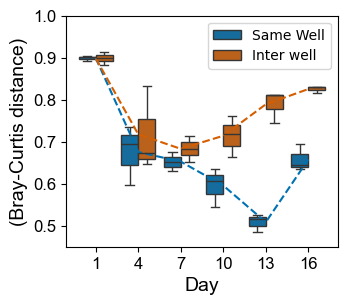

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the Bray–Curtis dataframe previously computed
df_Bray = df_braycurtis_disc

# Create a new figure for plotting
plt.figure(figsize=[3.5, 3])

# ------------------------------------------------------------
# Prepare SAME-WELL DISC comparisons (B1–B2, B2–B3, B1–B3)
# ------------------------------------------------------------

# Select Bray–Curtis distances for same-well comparisons
df_plot = df_Bray[['DiscA12','DiscA23','DiscA13']]

# Remove rows where DiscA23 is missing (ensures complete rows)
df_plot = df_plot.loc[pd.isna(df_plot.DiscA23) == False]

# Convert wide format → long format for plotting
df_data = pd.DataFrame(
    df_plot[['DiscA12','DiscA23','DiscA13']].T.stack()
).reset_index().rename(columns={'level_0':'Disc','level_1':'Day',0:'Bray'})

# Label these as “Same Well”
df_data['Sample'] = 'Same Well'

# ------------------------------------------------------------
# Prepare INTER-WELL DISC comparisons (A1–B1, A2–B2, A3–B3)
# ------------------------------------------------------------

df_plot2 = df_Bray[['DiscA1B1','DiscA2B2','DiscA3B3']]
df_plot2 = df_plot2.loc[pd.isna(df_plot2.DiscA2B2) == False]

# Wide → long format
df_data2 = pd.DataFrame(
    df_plot2[['DiscA1B1','DiscA2B2','DiscA3B3']].T.stack()
).reset_index().rename(columns={'level_0':'Disc','level_1':'Day',0:'Bray'})

# Label these as “Inter well”
df_data2['Sample'] = 'Inter well'

# Combine same-well and inter-well datasets
df_data3 = pd.concat([df_data, df_data2])

# ------------------------------------------------------------
# Plot boxplots comparing same-well vs inter-well Bray–Curtis
# ------------------------------------------------------------
sns.boxplot(
    x='Day', 
    y='Bray', 
    data=df_data3, 
    hue='Sample', 
    palette={"Same Well": "#0072B2", "Inter well": "#D55E00"}
)




# ------------------------------------------------------------
# Plot mean Bray–Curtis trend lines for each category
# ------------------------------------------------------------

# Mean across days for SAME-WELL
data = df_data[['Day','Bray']].groupby('Day').mean()
plt.plot([0,1,2,3,4,5], data.Bray, color='#0072B2', alpha=1, linestyle='--')

# Mean across days for INTER-WELL
data = df_data2[['Day','Bray']].groupby('Day').mean()
plt.plot([0,1,2,3,4,5], data.Bray, color='#D55E00', alpha=1, linestyle='--')

# ------------------------------------------------------------
# Formatting the figure
# ------------------------------------------------------------
plt.legend(ncol=1)

plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('(Bray-Curtis distance)',
           fontname='arial', fontsize=14)

plt.ylim([0.45,1])

plt.xticks([0,1,2,3,4,5], [1,4,7,10,13,16], fontname='Arial', fontsize=12)
plt.yticks(fontname='Arial', fontsize=12)

# Save figure
plt.savefig('Figures paper/DiscDisc_Braycurtis_intra_inter_B.svg',
            format='svg', dpi=300)


In [19]:
import numpy as np
import pandas as pd
from itertools import combinations, product

# --- ENRICHMENT THRESHOLD ---
cols = [f"t_{i}_enrichment" for i in range(8, 12)]
enrichment_values = [
    df_biofilm_filtered[col].mean() + 1.96 * df_biofilm_filtered[col].std()
    for col in cols
]
enrichment_threshold = np.mean(enrichment_values) + 1.96 * np.std(enrichment_values)

enrichment_threshold

# ------------------------------------------------------------
# TIMEPOINT DEFINITIONS FOR EACH DISC in replicate B
# Each group contains six timepoints for that disc
# ------------------------------------------------------------
B1 = ['15','51','87','123','151','175']
B2 = ['16','52','88','124','152','176']
B3 = ['17','53','89','125','153','177']

records = []

for i in range(len(B1)):
    mask = (
        (df_biofilm_filtered['t_'+B1[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B2[i]+'_enrichment'] < enrichment_threshold) &
        (df_biofilm_filtered['t_'+B3[i]+'_enrichment'] < enrichment_threshold)
    )
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B1[i]+'_f'].sum()
    records.append({
            'Sample': 'One disc',
            'Time': i,
            'Fraction': fraction_sum
        })
for i in range(len(B2)):
    mask = (
        (df_biofilm_filtered['t_'+B2[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B1[i]+'_enrichment'] < enrichment_threshold) &
        (df_biofilm_filtered['t_'+B3[i]+'_enrichment'] < enrichment_threshold)
    )
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B2[i]+'_f'].sum()
    records.append({
            'Sample': 'One disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    
for i in range(len(B3)):
    mask = (
        (df_biofilm_filtered['t_'+B3[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B1[i]+'_enrichment'] < enrichment_threshold) &
        (df_biofilm_filtered['t_'+B2[i]+'_enrichment'] < enrichment_threshold)
    )
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B3[i]+'_f'].sum()
    records.append({
            'Sample': 'One disc',
            'Time': i,
            'Fraction': fraction_sum
        })

for i in range(len(B1)):
    mask = (
        (df_biofilm_filtered['t_'+B1[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B2[i]+'_enrichment'] >= enrichment_threshold))
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B1[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B2[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })

for i in range(len(B1)):
    mask = (
        (df_biofilm_filtered['t_'+B1[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B3[i]+'_enrichment'] >= enrichment_threshold))
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B1[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B3[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    
for i in range(len(B1)):
    mask = (
        (df_biofilm_filtered['t_'+B2[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B3[i]+'_enrichment'] >= enrichment_threshold))
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B3[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B2[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })

df_probability_enrichment = pd.DataFrame(records)
df_probability_enrichment.loc[2,'Fraction'] = np.nan
df_probability_enrichment.loc[22,'Fraction'] = np.nan

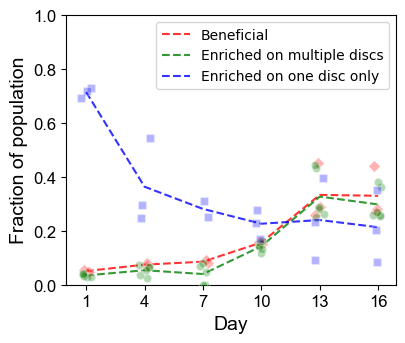

In [20]:

plt.figure(figsize = [4.25,3.5])

df_bene = pd.read_excel('Beneficial Fraction.xlsx', index_col=0)

# Red stripplot for Disc B distances
sns.stripplot(x='Time', y='Beneficial_fraction', data=df_bene, color='red', alpha=0.3,
              s=6, edgecolor='white',marker="D", linewidth=1, label = '' )

plt.plot([0,1,2,3,4,5], df_bene\
[['Time', 'Beneficial_fraction']].groupby('Time').mean(), '--', color = 'red', label = 'Beneficial', alpha = 0.8)



# Red-edged white boxplots for Disc B data
sns.stripplot(x='Time', y='Fraction', data=df_probability_enrichment.loc[df_probability_enrichment.Sample == 'Two disc'], color='green', alpha=0.3,
              s=6, edgecolor='white', linewidth=1, label = '' )

plt.plot([0,1,2,3,4,5], df_probability_enrichment.loc[df_probability_enrichment['Sample'] == 'Two disc']\
[['Time', 'Fraction']].groupby('Time').mean(), '--', color = 'green', label = 'Enriched on multiple discs', alpha = 0.8)


# Red-edged white boxplots for Disc B data
sns.stripplot(x='Time', y='Fraction', data=df_probability_enrichment.loc[df_probability_enrichment.Sample == 'One disc'], color='blue', alpha=0.3,
              s=6, edgecolor='white', marker="s", linewidth=1, label = '' )

plt.plot([0,1,2,3,4,5], df_probability_enrichment.loc[df_probability_enrichment['Sample'] == 'One disc']\
[['Time', 'Fraction']].groupby('Time').mean(), '--', color = 'blue', label = 'Enriched on one disc only', alpha = 0.8)

plt.xlabel('Day', fontname = 'Arial', fontsize = 14)
plt.ylabel('Fraction of population', fontname = 'Arial', fontsize = 14)
plt.legend(ncol = 1, fontsize = 10)



plt.xticks([0,1,2,3,4,5], [1,4,7,10,13,16], fontname='Arial', fontsize=12)
plt.yticks(fontname = 'Arial', fontsize = 12)

plt.ylim([0,1])

plt.savefig('Figures paper/Binding probability temporal.svg', format = 'svg', dpi = 300)

In [21]:
df_probability_enrichment.to_csv('Figurewise raw data/Supplementary Fig 10. Shared lineage fraction temporal.csv')